# Assistax Paper Plots

Pulls evaluation data from wandb artifacts and generates publication-quality figures.

In [2]:
import sys
import os

os.environ["JAX_PLATFORMS"] = "cpu"

# Ensure the project root is on the path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from assistax.baselines.paper_plots import (
    build_experiment_collection,
    plot_learning_curves,
    plot_normalized_learning_curves,
    plot_final_returns,
    plot_aggregate_normalized_returns,
    plot_shared_legend,
)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


## Configuration

Define which algorithms and environments to include. Each algorithm entry
specifies `base_tags` that will be combined with each environment name to
query wandb.

In [ ]:
EXPERIMENT_SPEC = {
    "algorithms": {
        "IPPO (FF)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_NPS"]},
        "IPPO (RNN)": {"base_tags": ["MARL_FINAL", "IPPO", "RNN_NPS"]},
        #"IPPO (FF, PS)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_PS"]},
        #"IPPO (RNN, PS)": {"base_tags": ["MARL_FINAL", "IPPO", "RNN_PS"]},
        "MAPPO (FF)": {"base_tags": ["MARL_FINAL", "MAPPO", "FF_NPS"]},
        "MAPPO (RNN)": {"base_tags": ["MARL_FINAL", "MAPPO", "RNN_NPS"]},
        #"ISAC": {"base_tags": ["MARL_FINAL", "ISAC"]},
        "MASAC": {"base_tags": ["MARL_FINAL", "MASAC", "FF_NPS"]},
    },
    "environments": [
        "scratchitch",
        "bedbathing",
        "armmanipulation",
        "scratchitch",
        "teethbrushing",
        "feeding"
],
}

#EXPERIMENT_SPEC = {"algorithms": {
#                    "IPPO (FF)": {"base_tags" ["MARL_FINAL", "IPPO", "FF_NPS", "PREF"]},
#                        },
#                    "environments": 
#                        ["armmanipulation"],
#                 
#EXPERIMENT_SPEC = {
#    "algorithms": {
#        "IPPO (FF)": {"base_tags": ["MARL_FINAL", "IPPO", "FF_NPS"]},
#        "IPPO (RNN)": {"base_tags": ["MARL_FINAL", "IPPO", "RNN_NPS"]},
#        "MAPPO (FF)": {"base_tags": ["MARL_FINAL", "MAPPO", "FF_NPS"]},
#    },
#    "environments": [
#        "armmanipulation",
#        "bedbathing",
#        "scratchitch",
#        "teethbrushing",
#        "feeding"
#    ],
#}

## Data Extraction

Download evaluation artifacts from wandb (cached locally after first fetch).

In [4]:
collection = build_experiment_collection(EXPERIMENT_SPEC, exclude_pref=False)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/leo/.netrc.


  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'scratchitch']
  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'scratchitch']
[WARN] Skipping IPPO (FF, PS) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'scratchitch']
[WARN] Skipping IPPO (RNN, PS) / scratchitch — no data found
  Found 2 runs for tags ['MARL_FINAL', 'MAPPO', 'FF_NPS', 'scratchitch']
  Found 13 runs for tags ['MARL_FINAL', 'MAPPO', 'RNN_NPS', 'scratchitch']
[WARN] Could not download artifact for run mappo_nps_rnn_scratchitch_2026-03-03_04-43-32_seed0: artifact membership 'evaluation_data_mappo_nps_rnn_scratchitch_2026-03-03_04-43-32_seed0:latest' not found in 'lh-from-kb/assistax-dev'
[WARN] Could not download artifact for run mappo_nps_rnn

wandb: Downloading large artifact 'evaluation_data_mappo_nps_rnn_scratchitch_2026-03-04_12-11-38_seed3:latest', 1950.13MB. 21 files...
wandb:   21 of 21 files downloaded.  
Done. 00:00:23.1 (84.4MB/s)


[WARN] Could not download artifact for run mappo_nps_rnn_scratchitch_2026-03-04_14-39-35_seed4: artifact membership 'evaluation_data_mappo_nps_rnn_scratchitch_2026-03-04_14-39-35_seed4:latest' not found in 'lh-from-kb/assistax-dev'
  Found 2 runs for tags ['MARL_FINAL', 'MASAC', 'FF_NPS', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'bedbathing']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'bedbathing']
[WARN] Skipping IPPO (FF) / bedbathing — no data found
  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'bedbathing']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'bedbathing']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'bedbathing']
[WARN] Skipping IPPO (FF, PS) / bedbathing — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'bedbathing']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'bedbathing']
[WARN] Skipping IPPO (RNN, PS) / bedbathing — no data found
  Found

wandb: Downloading large artifact 'evaluation_data_mappo_nps_rnn_teethbrushing_2026-03-04_12-15-04_seed3:latest', 2196.32MB. 23 files...
wandb:   23 of 23 files downloaded.  
Done. 00:00:25.0 (87.7MB/s)


[WARN] Could not download artifact for run mappo_nps_rnn_teethbrushing_2026-03-04_14-01-59_seed4: artifact membership 'evaluation_data_mappo_nps_rnn_teethbrushing_2026-03-04_14-01-59_seed4:latest' not found in 'lh-from-kb/assistax-dev'
  Found 0 runs for tags ['MARL_FINAL', 'MASAC', 'FF_NPS', 'teethbrushing']
[WARN] No runs found for tags ['MARL_FINAL', 'MASAC', 'FF_NPS', 'teethbrushing']
[WARN] Skipping MASAC / teethbrushing — no data found
  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'feeding']
  Found 2 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'feeding']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'feeding']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'feeding']
[WARN] Skipping IPPO (FF, PS) / feeding — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'feeding']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'feeding']
[WARN] Skipping IPPO (RNN, PS) / feeding — no data found
  Found 2 runs for tag

In [5]:
# Inspect what was loaded
print(f"Environments: {collection.env_names}")
print(f"Algorithms:   {collection.algo_names}")
for env in collection.env_names:
    for algo, ad in collection.data[env].items():
        print(f"  {env} / {algo}: {ad.returns.shape}")

Environments: ['armmanipulation', 'bedbathing', 'feeding', 'scratchitch', 'teethbrushing']
Algorithms:   ['IPPO (FF)', 'IPPO (RNN)', 'MAPPO (FF)', 'MAPPO (RNN)', 'MASAC']
  armmanipulation / IPPO (FF): (16, 610)
  armmanipulation / IPPO (RNN): (16, 610)
  armmanipulation / MAPPO (FF): (32, 610)
  armmanipulation / MAPPO (RNN): (20, 610)
  bedbathing / IPPO (RNN): (16, 610)
  bedbathing / MAPPO (FF): (32, 610)
  bedbathing / MAPPO (RNN): (16, 610)
  feeding / IPPO (FF): (32, 610)
  feeding / IPPO (RNN): (16, 610)
  feeding / MAPPO (FF): (32, 610)
  feeding / MAPPO (RNN): (24, 610)
  scratchitch / IPPO (FF): (32, 610)
  scratchitch / IPPO (RNN): (16, 610)
  scratchitch / MAPPO (FF): (32, 610)
  scratchitch / MAPPO (RNN): (24, 610)
  scratchitch / MASAC: (32, 256)
  teethbrushing / IPPO (FF): (64, 610)
  teethbrushing / IPPO (RNN): (16, 610)
  teethbrushing / MAPPO (FF): (32, 610)
  teethbrushing / MAPPO (RNN): (28, 610)


## Learning Curves per Environment

Saved figure to figs/armmanipulation_learning_curves.pdf
Saved figure to figs/bedbathing_learning_curves.pdf
Saved figure to figs/feeding_learning_curves.pdf
Saved figure to figs/scratchitch_learning_curves.pdf
Saved figure to figs/teethbrushing_learning_curves.pdf


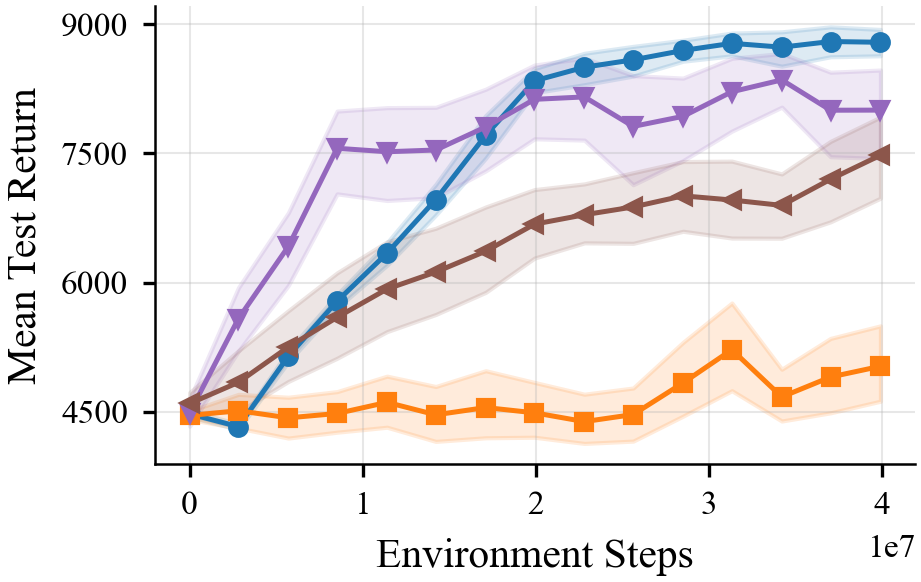

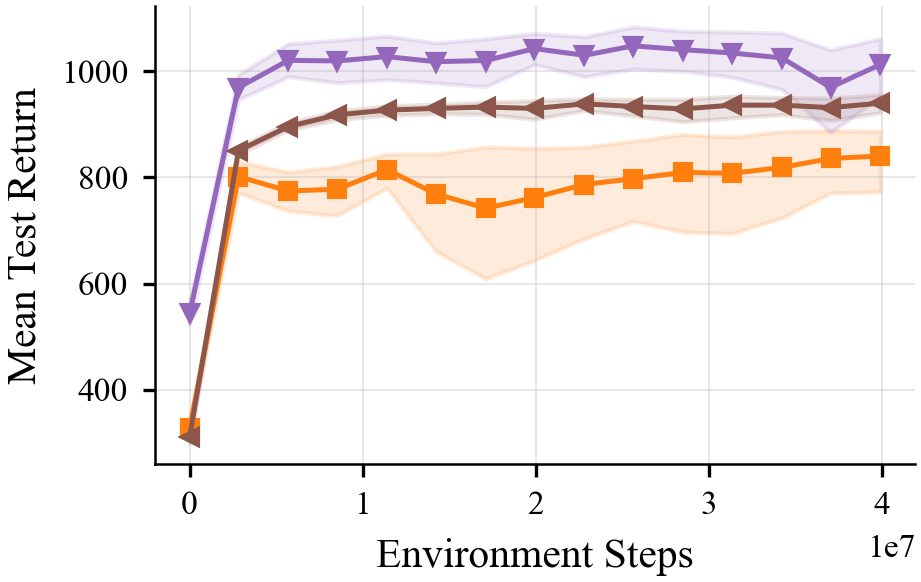

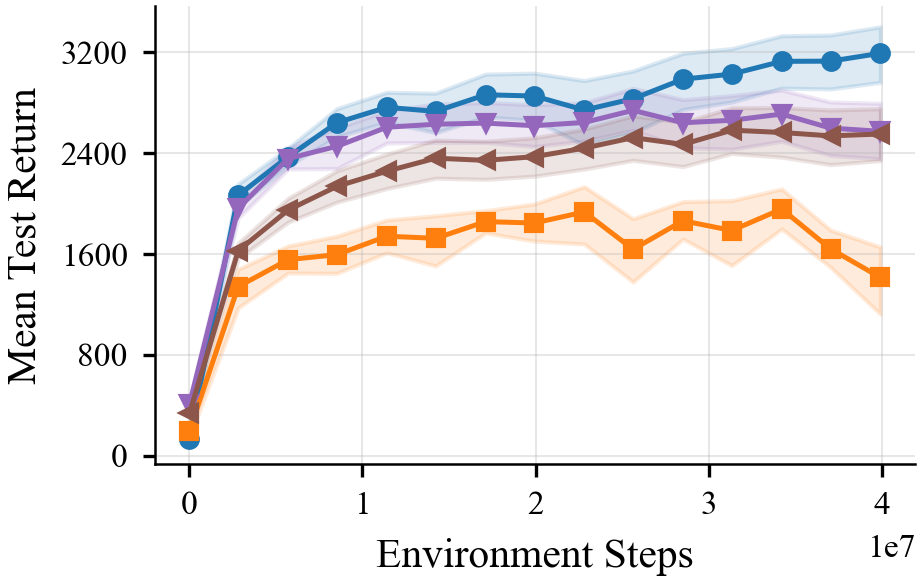

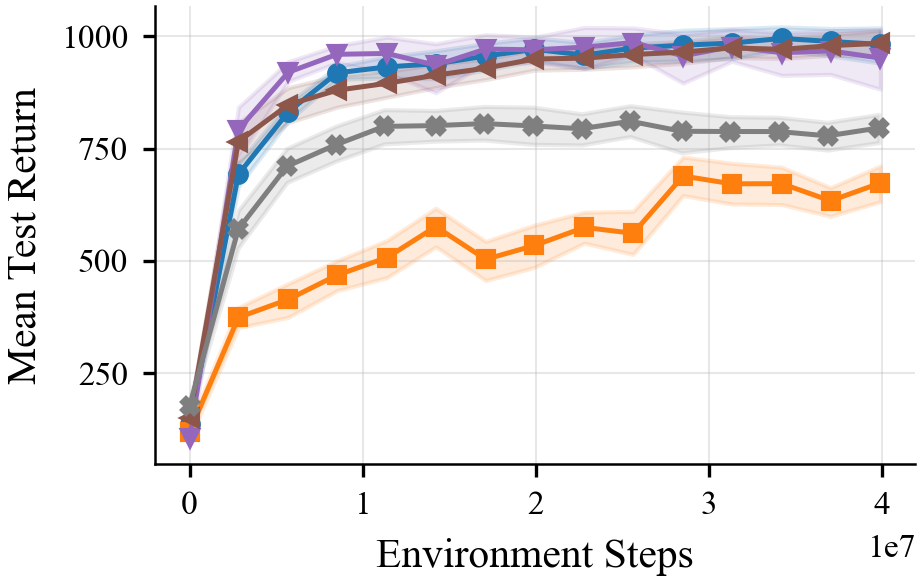

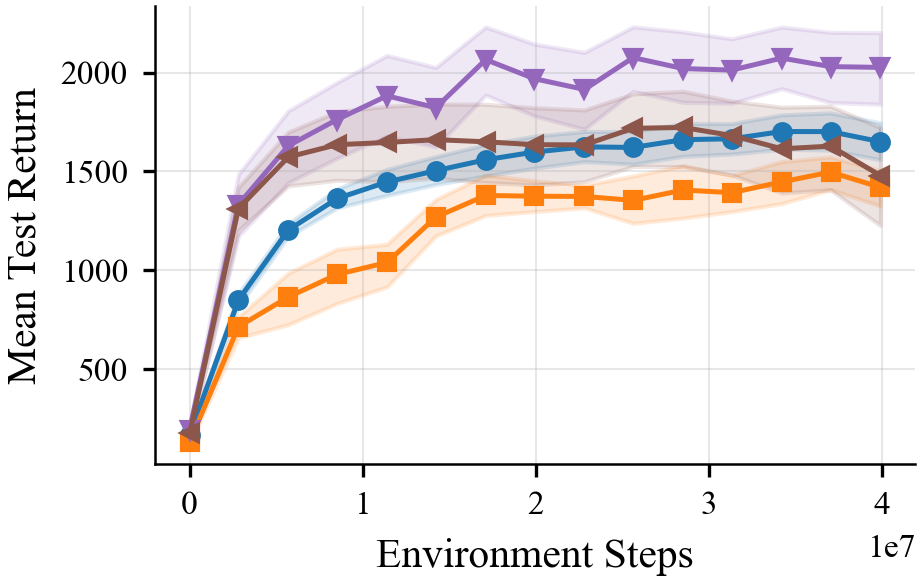

In [21]:
plot_learning_curves(
    collection,
    n_subsample=15,
    save_dir="figs/",
    usetex_fallback=True,
)

In [22]:
plot_shared_legend(
    collection.algo_names,
    save_path="figs/shared_legend.pdf",
    usetex_fallback=True,
)

Saved figure to figs/shared_legend.pdf


<Figure size 2025x120 with 0 Axes>

## Normalized Learning Curves (Aggregate)

Saved figure to figs/norm_curves.pdf


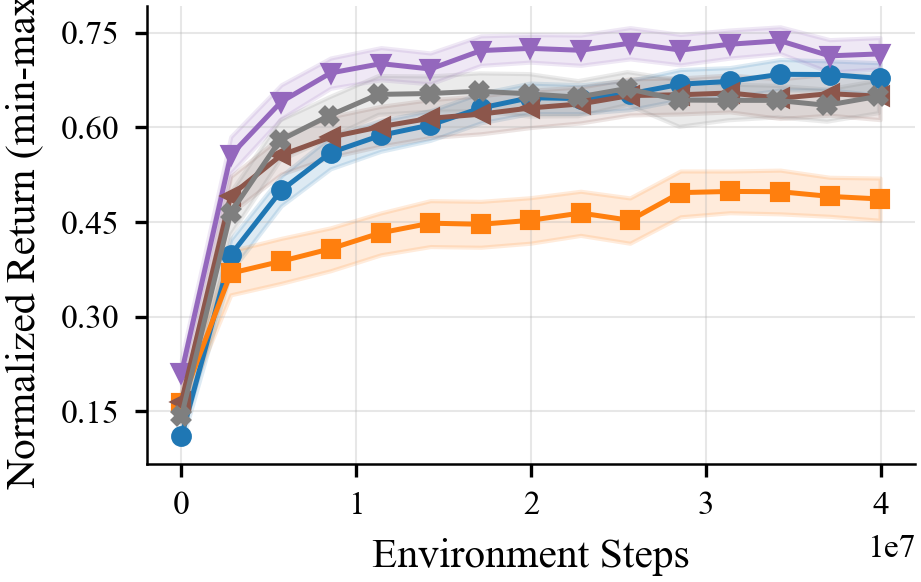

In [23]:
plot_normalized_learning_curves(
    collection,
    n_subsample=15,
    save_path="figs/norm_curves.pdf",
    usetex_fallback=True,
    normalization="minmax"
)

## Final Returns per Environment

Saved figure to figs/armmanipulation_final_returns.pdf
Saved figure to figs/bedbathing_final_returns.pdf
Saved figure to figs/feeding_final_returns.pdf
Saved figure to figs/scratchitch_final_returns.pdf
Saved figure to figs/teethbrushing_final_returns.pdf


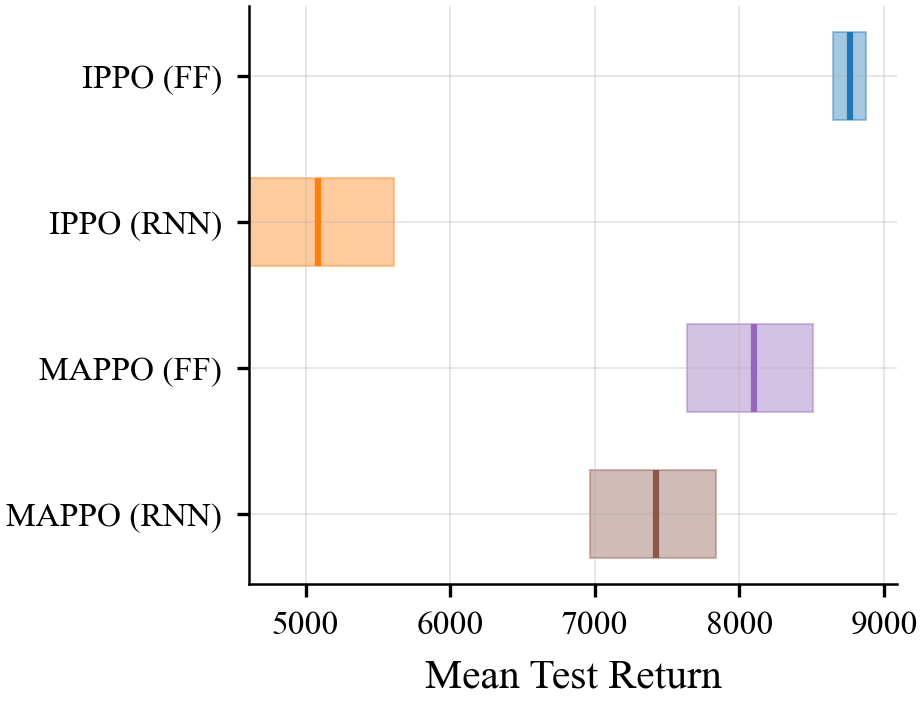

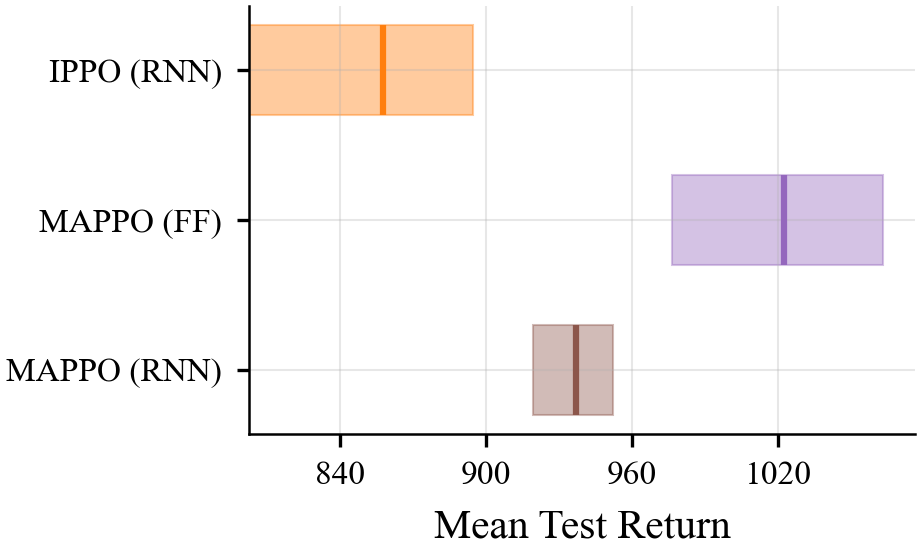

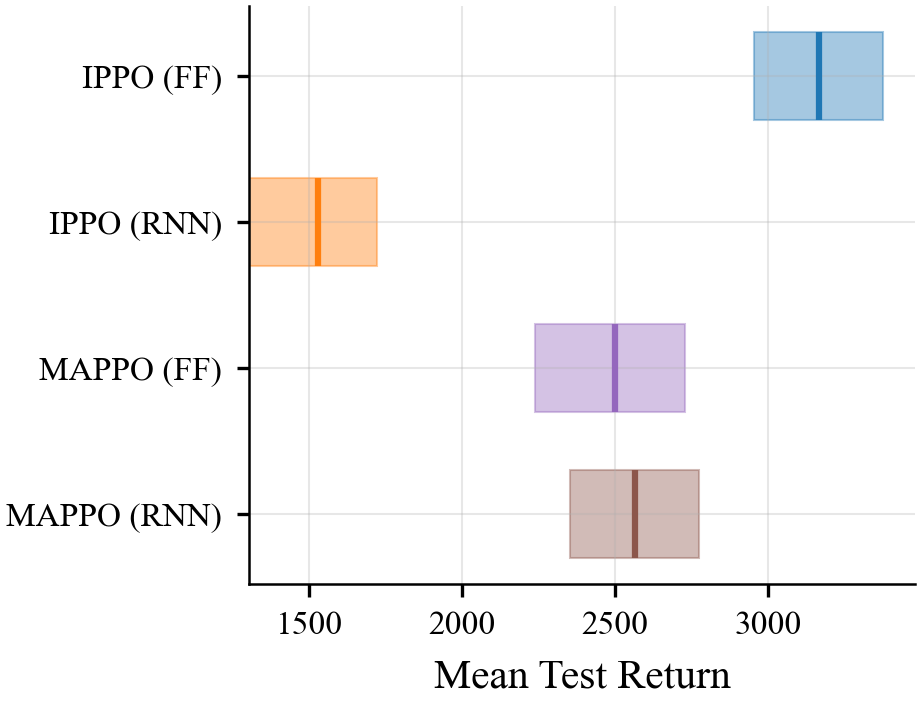

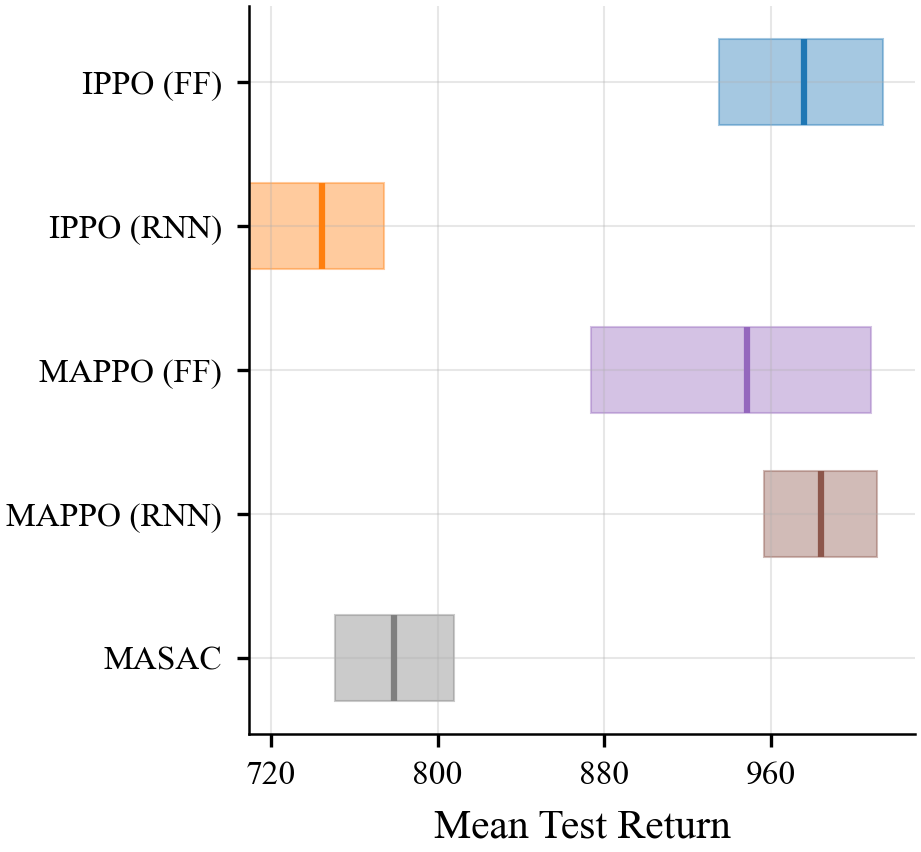

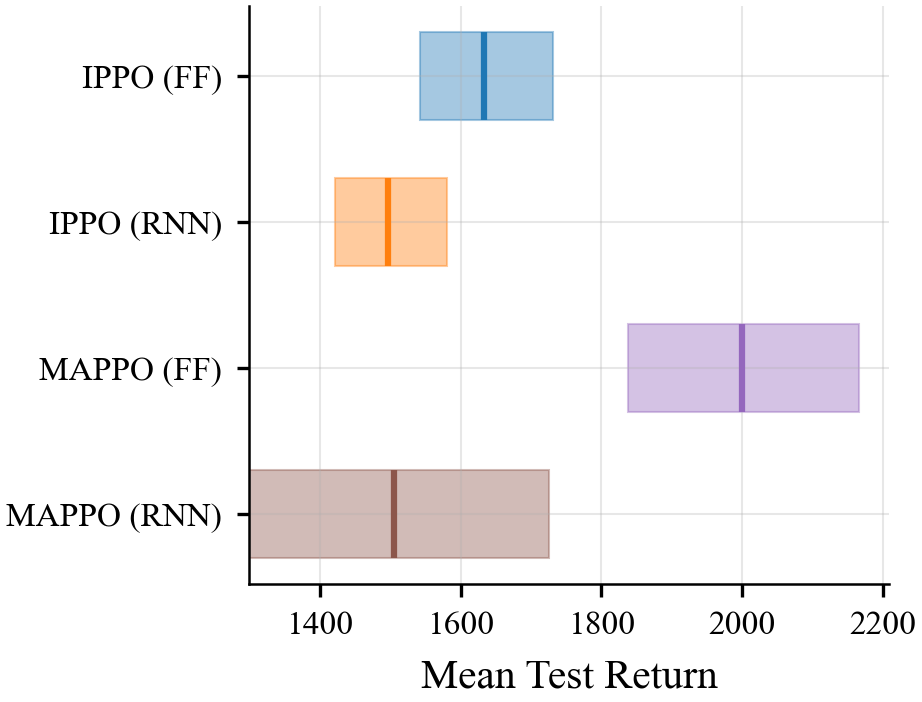

In [9]:
plot_final_returns(
    collection,
    final_n=10,
    save_dir="figs/",
    usetex_fallback=True,
)

## Aggregate Normalized Final Returns

Saved figure to figs/agg_norm.pdf


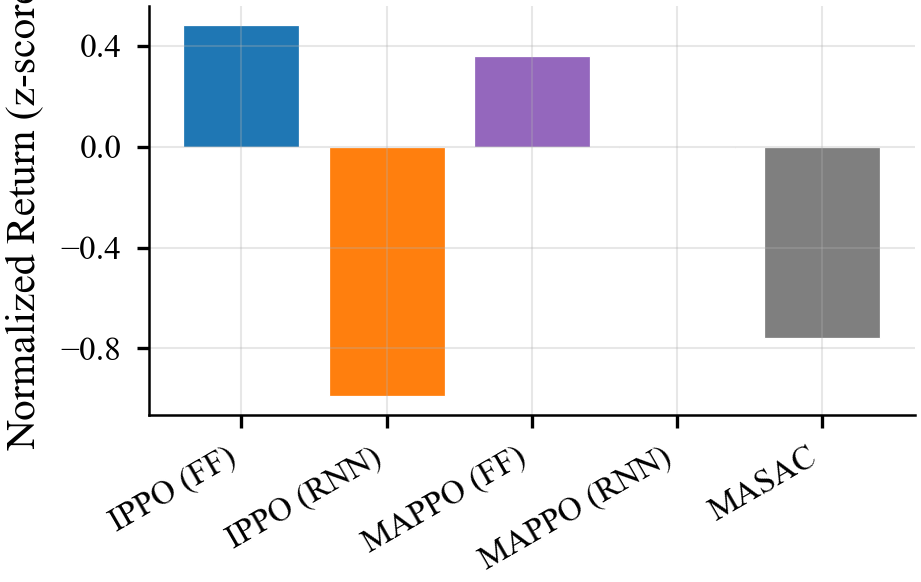

In [10]:
plot_aggregate_normalized_returns(
    collection,
    final_n=10,
    save_path="figs/agg_norm.pdf",
    usetex_fallback=True,
)

## Min-Max Normalized Aggregate Plots

Saved figure to figs/norm_curves_minmax.pdf
Saved figure to figs/agg_norm_minmax.pdf


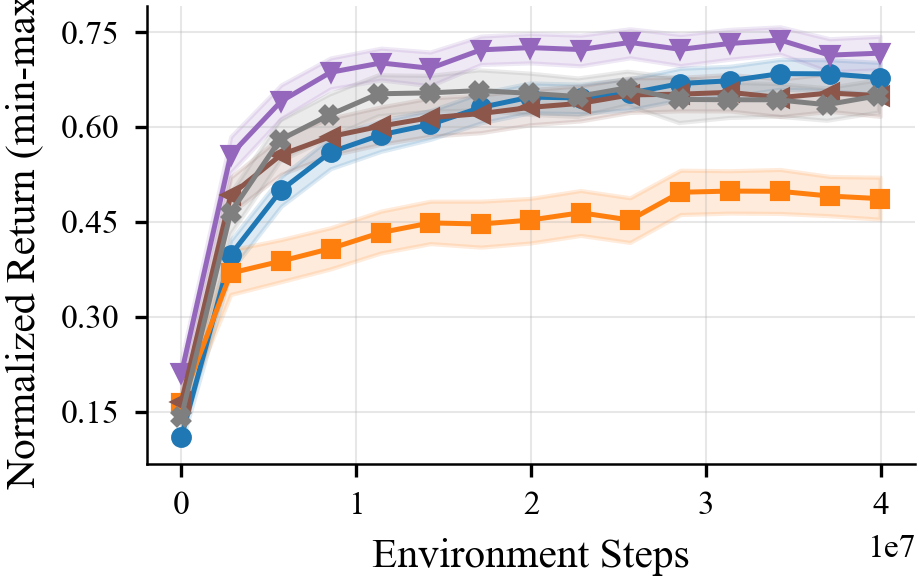

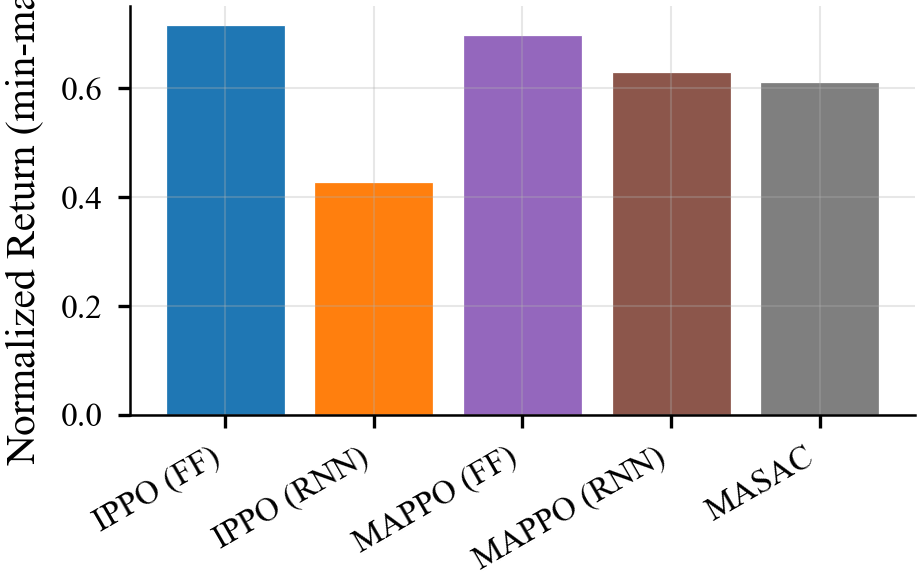

In [24]:
plot_normalized_learning_curves(
    collection,
    n_subsample=15,
    normalization="minmax",
    save_path="figs/norm_curves_minmax.pdf",
    usetex_fallback=True,
)

plot_aggregate_normalized_returns(
    collection,
    final_n=15,
    normalization="minmax",
    save_path="figs/agg_norm_minmax.pdf",
    usetex_fallback=True,
)

## PREF vs Non-PREF Comparison

Build a second collection that includes the `PREF` tag and compare
side-by-side with the non-PREF collection above.

In [12]:
# Build PREF collection
PREF_SPEC = {
    "algorithms": {
        algo_name: {
            "base_tags": cfg["base_tags"] + ["PREF"]
        }
        for algo_name, cfg in EXPERIMENT_SPEC["algorithms"].items()
    },
    "environments": EXPERIMENT_SPEC["environments"],
}

pref_collection = build_experiment_collection(PREF_SPEC, exclude_pref=False)

  Found 1 runs for tags ['MARL_FINAL', 'IPPO', 'FF_NPS', 'PREF', 'scratchitch']
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (RNN) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'FF_PS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (FF, PS) / scratchitch — no data found
  Found 0 runs for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'PREF', 'scratchitch']
[WARN] No runs found for tags ['MARL_FINAL', 'IPPO', 'RNN_PS', 'PREF', 'scratchitch']
[WARN] Skipping IPPO (RNN, PS) / scratchitch — no data found
  Found 1 runs for tags ['MARL_FINAL', 'MAPPO', 'FF_NPS', 'PREF', 'scratchitch']
  Found 4 runs for tags ['MARL_FINAL', 'MAPPO', 'RNN_NPS', 'PREF', 'scratchitch']
[WARN] Could not download artifact for run mappo_nps_rnn_scratchitch_2026-03-04_1

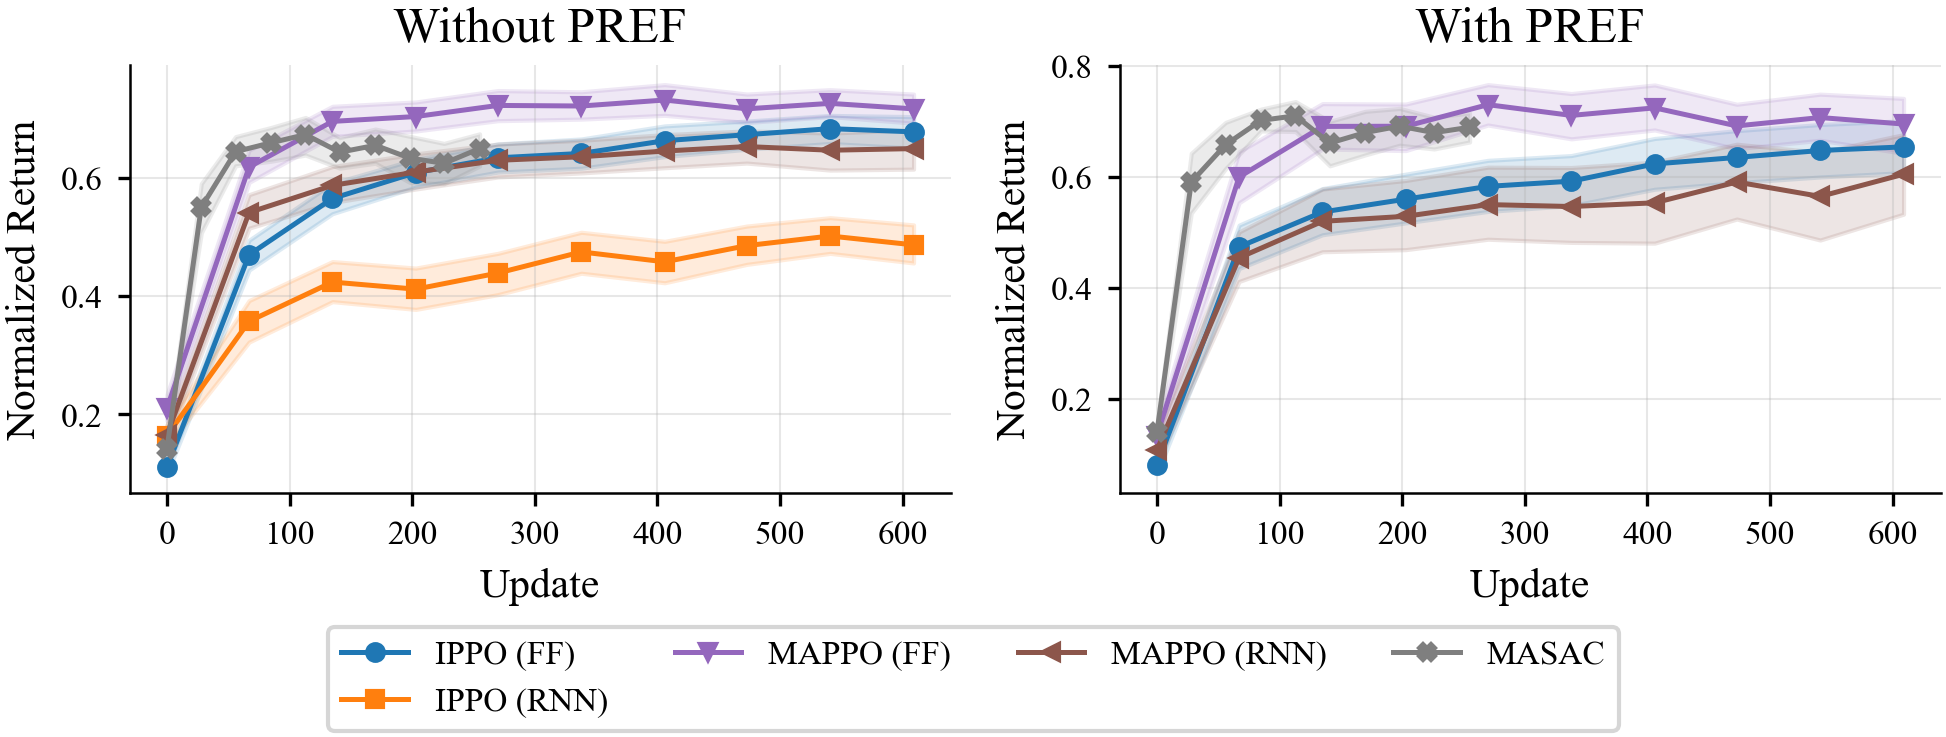

In [13]:
# Side-by-side learning curves: non-PREF (left) vs PREF (right)
import matplotlib.pyplot as plt
from assistax.baselines.paper_plots import set_paper_style, PAPER_FULL_WIDTH

set_paper_style(usetex_fallback=True)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(PAPER_FULL_WIDTH, 2.5))

for ax, coll, title in [
    (ax_left, collection, "Without PREF"),
    (ax_right, pref_collection, "With PREF"),
]:
    from assistax.baselines.paper_plots import (
        minmax_normalize_curves, subsample_curve, bootstrap_ci_mean,
        _get_color, _get_marker,
    )
    from assistax.baselines.sweep_plots import bootstrap_ci_mean
    import numpy as np

    norm_curves = minmax_normalize_curves(coll)
    algo_agg = {}
    for env_name in coll.env_names:
        for algo_name, norm_arr in norm_curves[env_name].items():
            algo_agg.setdefault(algo_name, []).append(norm_arr)

    for algo_name in sorted(algo_agg.keys()):
        arrs = algo_agg[algo_name]
        min_len = min(a.shape[1] for a in arrs)
        stacked = np.concatenate([a[:, :min_len] for a in arrs], axis=0)
        sub_data, sub_idx = subsample_curve(stacked, 10)
        mean, lower, upper = bootstrap_ci_mean(sub_data)
        color = _get_color(algo_name)
        marker = _get_marker(algo_name)
        ax.plot(sub_idx, mean, color=color, marker=marker, label=algo_name)
        ax.fill_between(sub_idx, lower, upper, color=color, alpha=0.15)

    ax.set_title(title)
    ax.set_xlabel("Update")
    ax.set_ylabel("Normalized Return")

handles, labels = ax_left.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("figs/pref_comparison.pdf")
plt.show()

Saved figure to figs/pref_comparison_without.pdf
Saved figure to figs/pref_comparison_with.pdf


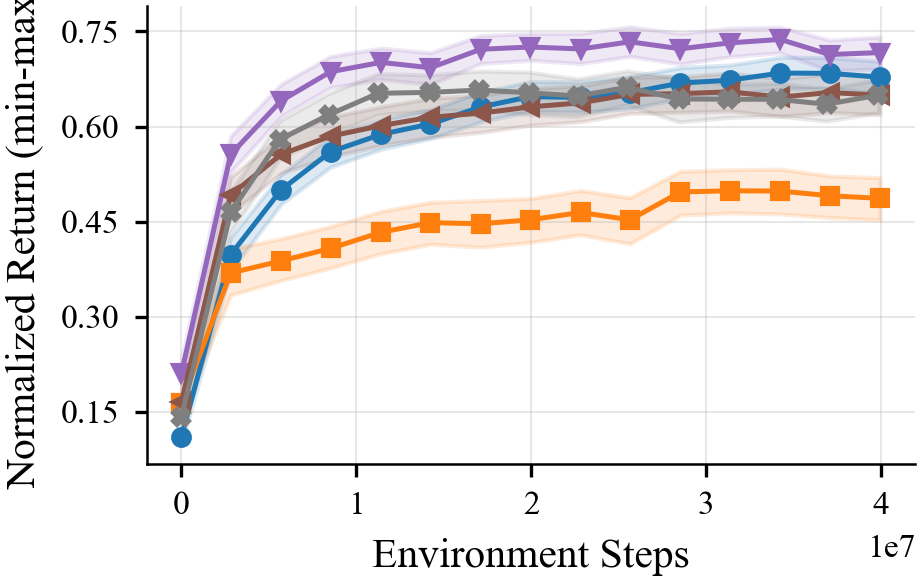

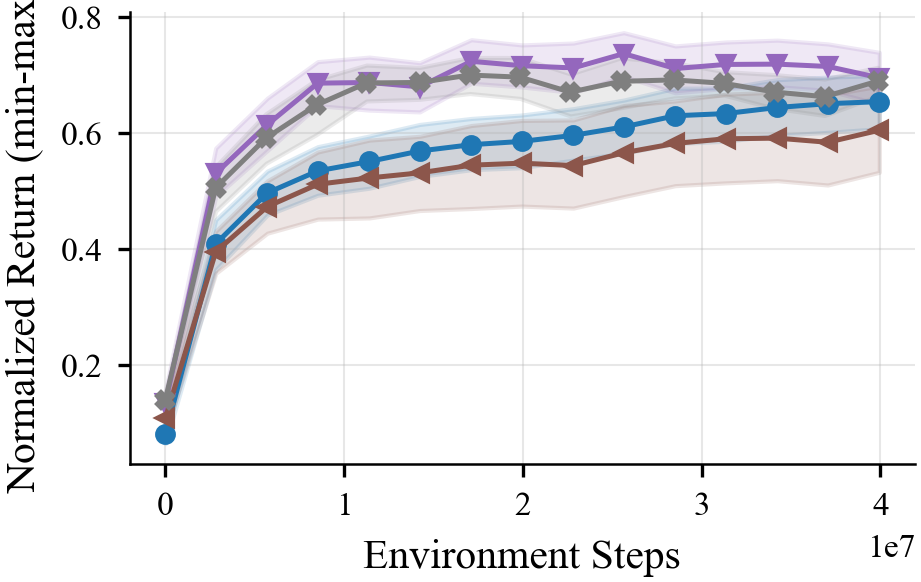

In [27]:
# Separate aggregate normalized plots for pref comparison
plot_normalized_learning_curves(
    collection, n_subsample=15,
    save_path="figs/pref_comparison_without.pdf",
    usetex_fallback=True,
    normalization="minmax",
)
plot_normalized_learning_curves(
    pref_collection, n_subsample=15,
    save_path="figs/pref_comparison_with.pdf",
    usetex_fallback=True,
    normalization="minmax",
)

Saved figure to figs/armmanipulation_pref_comparison.pdf
Saved figure to figs/bedbathing_pref_comparison.pdf
Saved figure to figs/feeding_pref_comparison.pdf
Saved figure to figs/scratchitch_pref_comparison.pdf
Saved figure to figs/teethbrushing_pref_comparison.pdf


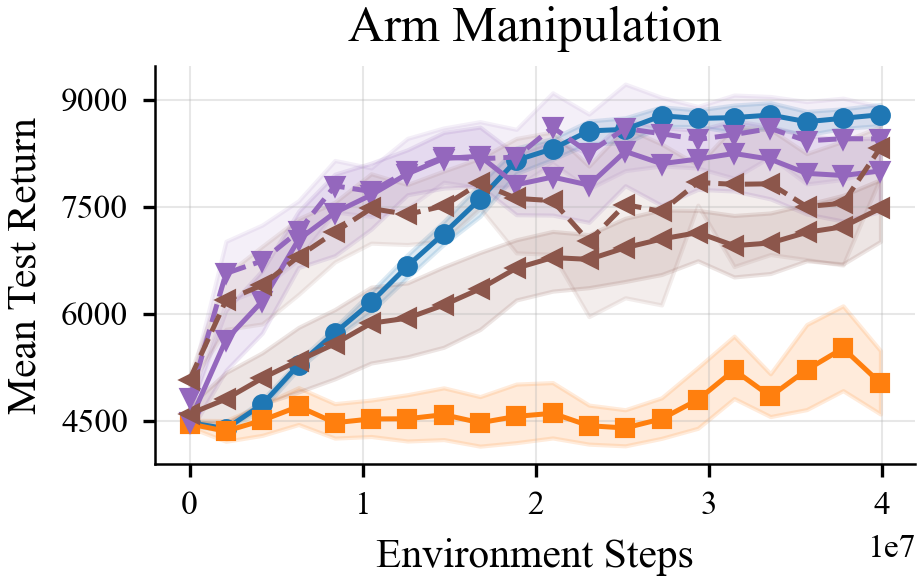

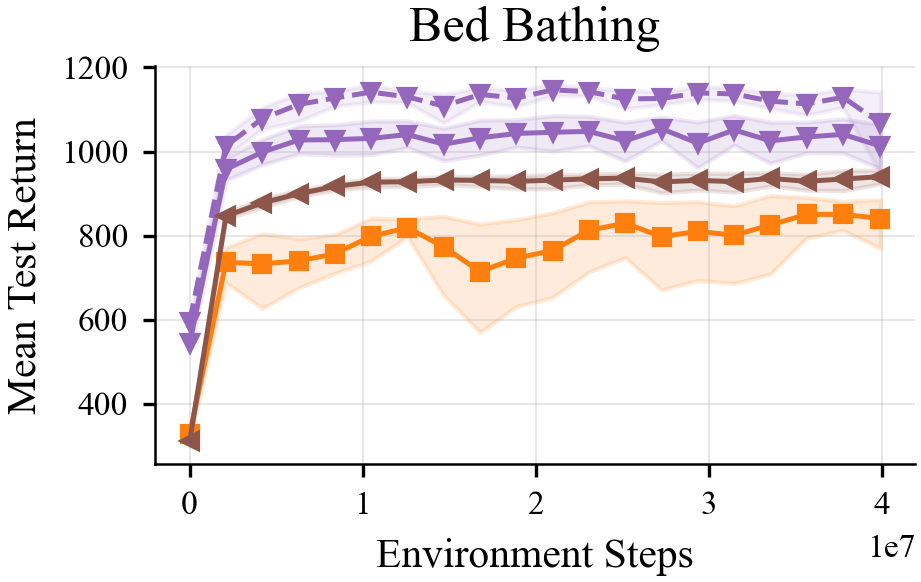

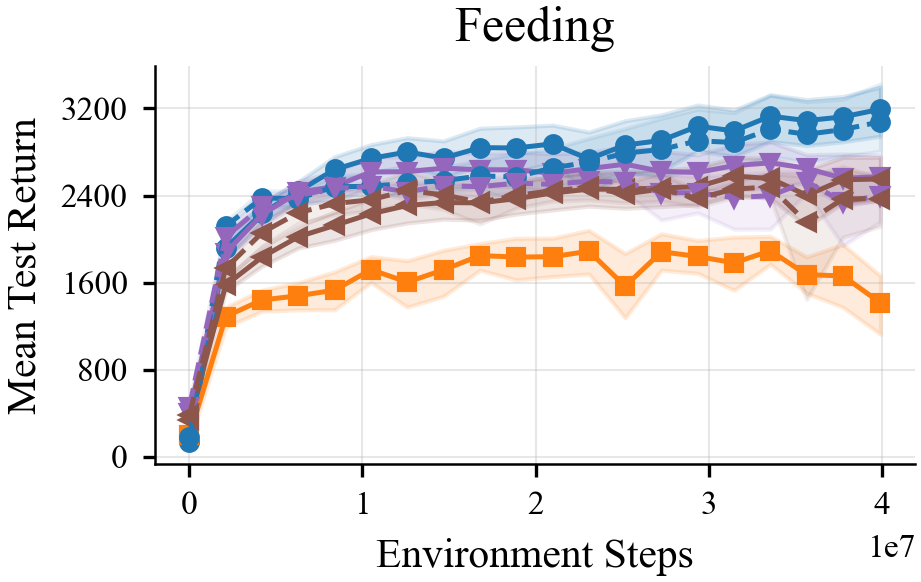

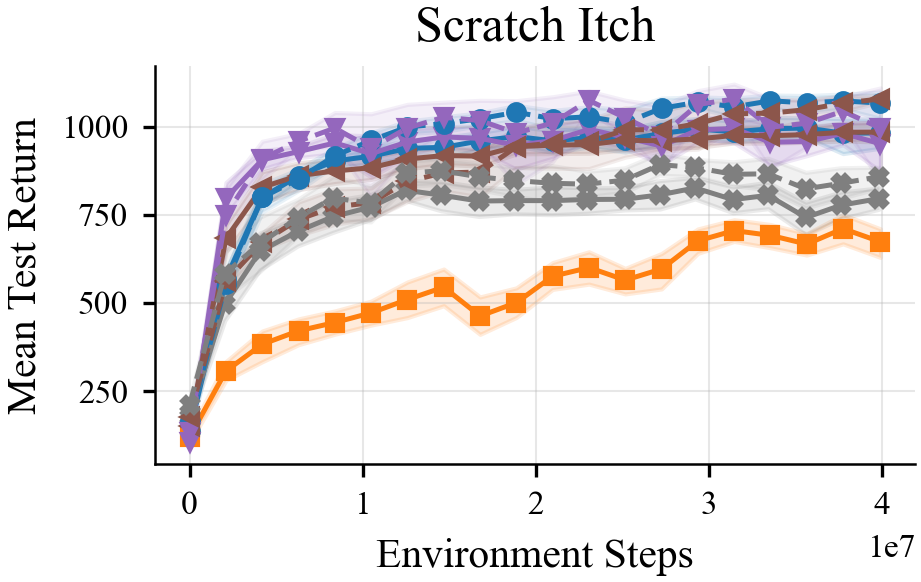

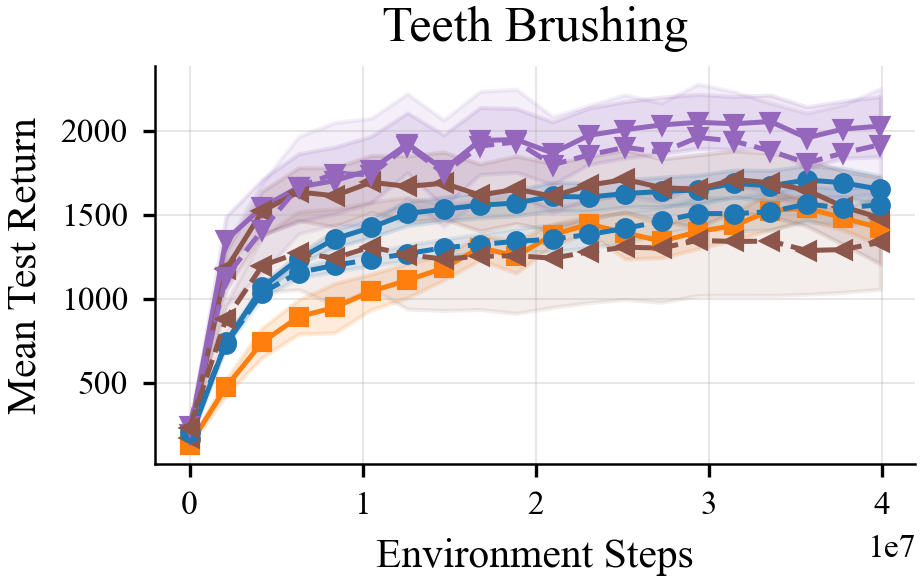

In [15]:
# Per-environment pref vs no-pref comparison (overlaid)
from assistax.baselines.paper_plots import (
    set_paper_style, PAPER_COLUMN_WIDTH, subsample_curve,
    _get_color, _get_marker, _env_steps_axis, _env_display, _save_or_show,
)
from assistax.baselines.sweep_plots import bootstrap_ci_mean
import matplotlib.ticker as ticker

set_paper_style(usetex_fallback=True)

all_envs = sorted(set(collection.env_names) | set(pref_collection.env_names))

for env_name in all_envs:
    fig, ax = plt.subplots(figsize=(PAPER_COLUMN_WIDTH, 2.2))

    # Plot non-pref (solid)
    if env_name in collection.data:
        for algo_name in sorted(collection.data[env_name].keys()):
            ad = collection.data[env_name][algo_name]
            sub_data, sub_idx = subsample_curve(ad.returns, 20)
            x_vals = _env_steps_axis(ad, sub_idx)
            mean, lower, upper = bootstrap_ci_mean(sub_data)
            color = _get_color(algo_name)
            marker = _get_marker(algo_name)
            ax.plot(x_vals, mean, color=color, marker=marker,
                    linestyle="-", label=f"{algo_name}")
            ax.fill_between(x_vals, lower, upper, color=color, alpha=0.15)

    # Plot pref (dashed)
    if env_name in pref_collection.data:
        for algo_name in sorted(pref_collection.data[env_name].keys()):
            ad = pref_collection.data[env_name][algo_name]
            sub_data, sub_idx = subsample_curve(ad.returns, 20)
            x_vals = _env_steps_axis(ad, sub_idx)
            mean, lower, upper = bootstrap_ci_mean(sub_data)
            color = _get_color(algo_name)
            marker = _get_marker(algo_name)
            ax.plot(x_vals, mean, color=color, marker=marker,
                    linestyle="--", label=f"{algo_name} (PREF)")
            ax.fill_between(x_vals, lower, upper, color=color, alpha=0.10)

    ax.set_title(_env_display(env_name))
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Mean Test Return")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    fig.tight_layout()
    _save_or_show(fig, f"figs/{env_name}_pref_comparison.pdf")

In [16]:
# Standalone legend for per-env pref comparison plots
from matplotlib.lines import Line2D
from assistax.baselines.paper_plots import (
    set_paper_style, PAPER_FULL_WIDTH, _get_color, _get_marker, _save_or_show,
)

set_paper_style(usetex_fallback=True)

# Collect all algorithm names across both collections
all_algo_names = sorted(
    set(collection.algo_names) | set(pref_collection.algo_names)
)

handles = []
labels = []
for name in all_algo_names:
    color = _get_color(name)
    marker = _get_marker(name)
    # Non-pref (solid)
    handles.append(Line2D(
        [0], [0], color=color, marker=marker, linestyle="-",
        linewidth=1.2, markersize=4,
    ))
    labels.append(f"{name}")
    # PREF (dashed)
    handles.append(Line2D(
        [0], [0], color=color, marker=marker, linestyle="--",
        linewidth=1.2, markersize=4,
    ))
    labels.append(f"{name} (PREF)")

fig = plt.figure(figsize=(PAPER_FULL_WIDTH, 0.6))
fig.legend(
    handles=handles,
    labels=labels,
    loc="center",
    ncol=min(len(handles), 8),
    frameon=False,
    fontsize=7,
)
fig.tight_layout()
_save_or_show(fig, "figs/pref_comparison_legend.pdf")

Saved figure to figs/pref_comparison_legend.pdf


<Figure size 2025x180 with 0 Axes>

## AHT Learning Curves

In [17]:
from assistax.baselines.aht_plots import build_aht_collection, plot_aht_learning_curves, plot_aht_shared_legend

AHT_EXPERIMENT_SPEC = {
    "algorithms": {
        "PPO AHT (FF)": {
            "base_tags": ["ppo_aht", "AHT_FINAL"],
            "network_filter": {"recurrent": False, "agent_param_sharing": False},
        },
    },
    "environments": ["feeding",
                     "armmanipulation",
                     "bedbathing",
                     "scratchitch",
                     "teethbrushing"],
}

aht_collection = build_aht_collection(AHT_EXPERIMENT_SPEC)

  Found 1 runs for tags ['ppo_aht', 'AHT_FINAL', 'feeding']
  After network filter {'recurrent': False, 'agent_param_sharing': False}: 1/1 runs
[WARN] Could not download artifact 'evaluation_data_ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0_train_partners:latest' for run ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0: artifact membership 'evaluation_data_ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0_train_partners:latest' not found in 'lh-from-kb/assistax-dev'
[WARN] Could not download artifact 'evaluation_data_ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0_test_partners:latest' for run ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0: artifact membership 'evaluation_data_ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0_test_partners:latest' not found in 'lh-from-kb/assistax-dev'
  Loaded version-based artifacts for run ppo_aht_nps_ff_feeding_2026-03-03_00-45-34_seed0, auto-detecting train/test...
  [INFO] Summary scalars not found for run ppo_aht_nps_ff_feeding_2026-03-03_0

Saved figure to figs/feeding_aht_learning_curves.pdf
Saved figure to figs/scratchitch_aht_learning_curves.pdf
Saved figure to figs/teethbrushing_aht_learning_curves.pdf
Saved figure to figs/aht_legend.pdf


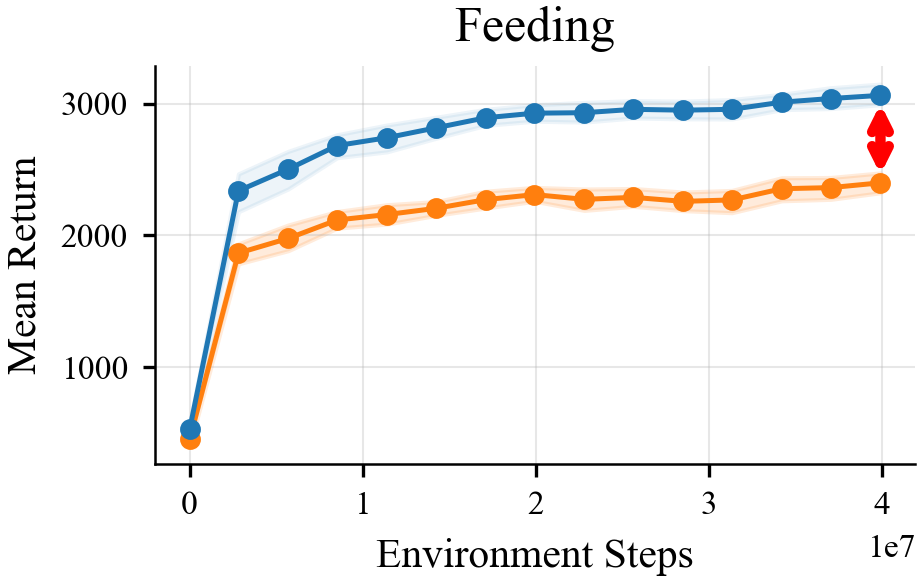

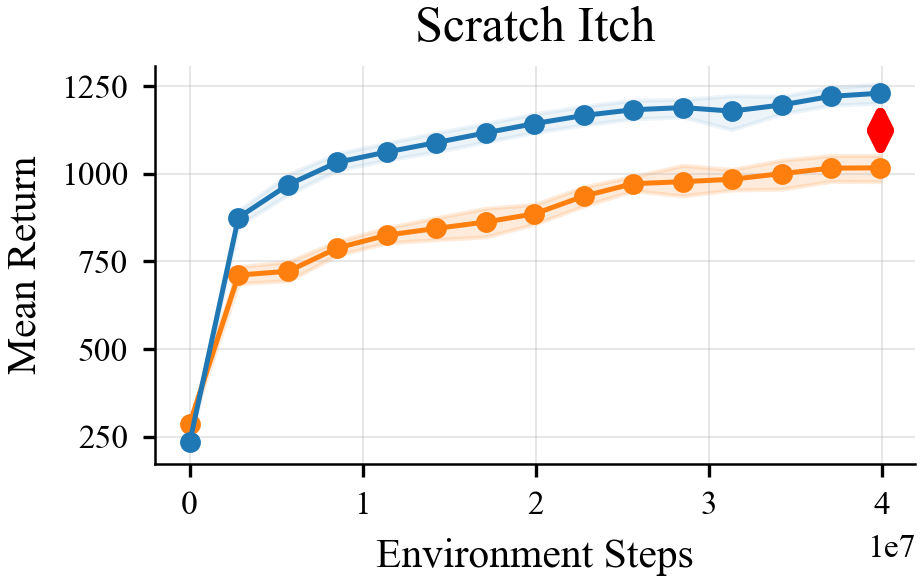

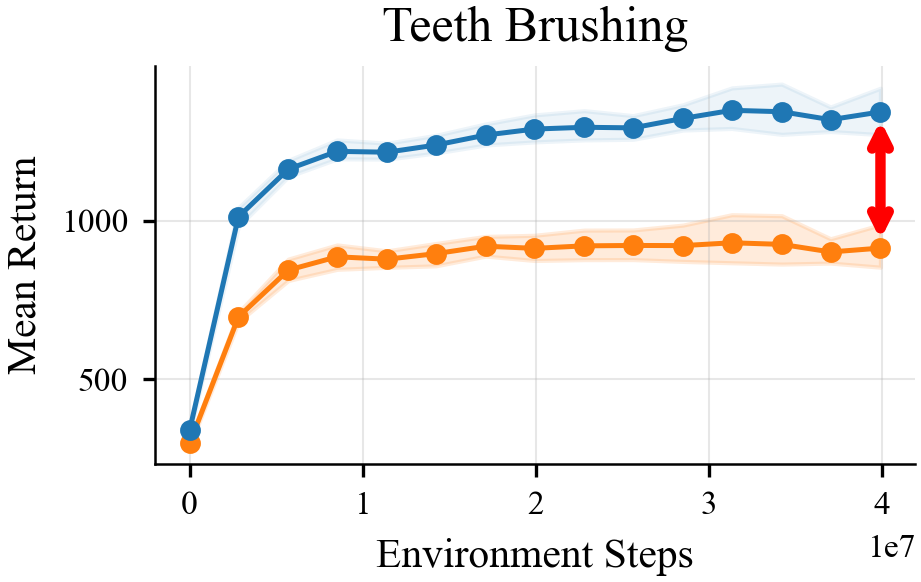

<Figure size 2025x180 with 0 Axes>

In [26]:
plot_aht_learning_curves(
    aht_collection,
    n_subsample=15,
    save_dir="figs/",
    usetex_fallback=True,
)

plot_aht_shared_legend(
    aht_collection.algo_names,
    save_path="figs/aht_legend.pdf",
    usetex_fallback=True,
)

## Crossplay Heatmaps

Saved: figs/crossplay_ippo.png
Saved: figs/crossplay_mappo.png
Saved: figs/crossplay_masac.png


{'IPPO': (<Figure size 1710x1710 with 2 Axes>,
  <Axes: title={'center': 'IPPO — Scratch Itch'}, xlabel='Human policy index', ylabel='Robot policy index'>),
 'MAPPO': (<Figure size 2025x2025 with 2 Axes>,
  <Axes: title={'center': 'MAPPO — Scratch Itch'}, xlabel='Human policy index', ylabel='Robot policy index'>),
 'MASAC': (<Figure size 2025x2025 with 2 Axes>,
  <Axes: title={'center': 'MASAC — Scratch Itch'}, xlabel='Human policy index', ylabel='Robot policy index'>)}

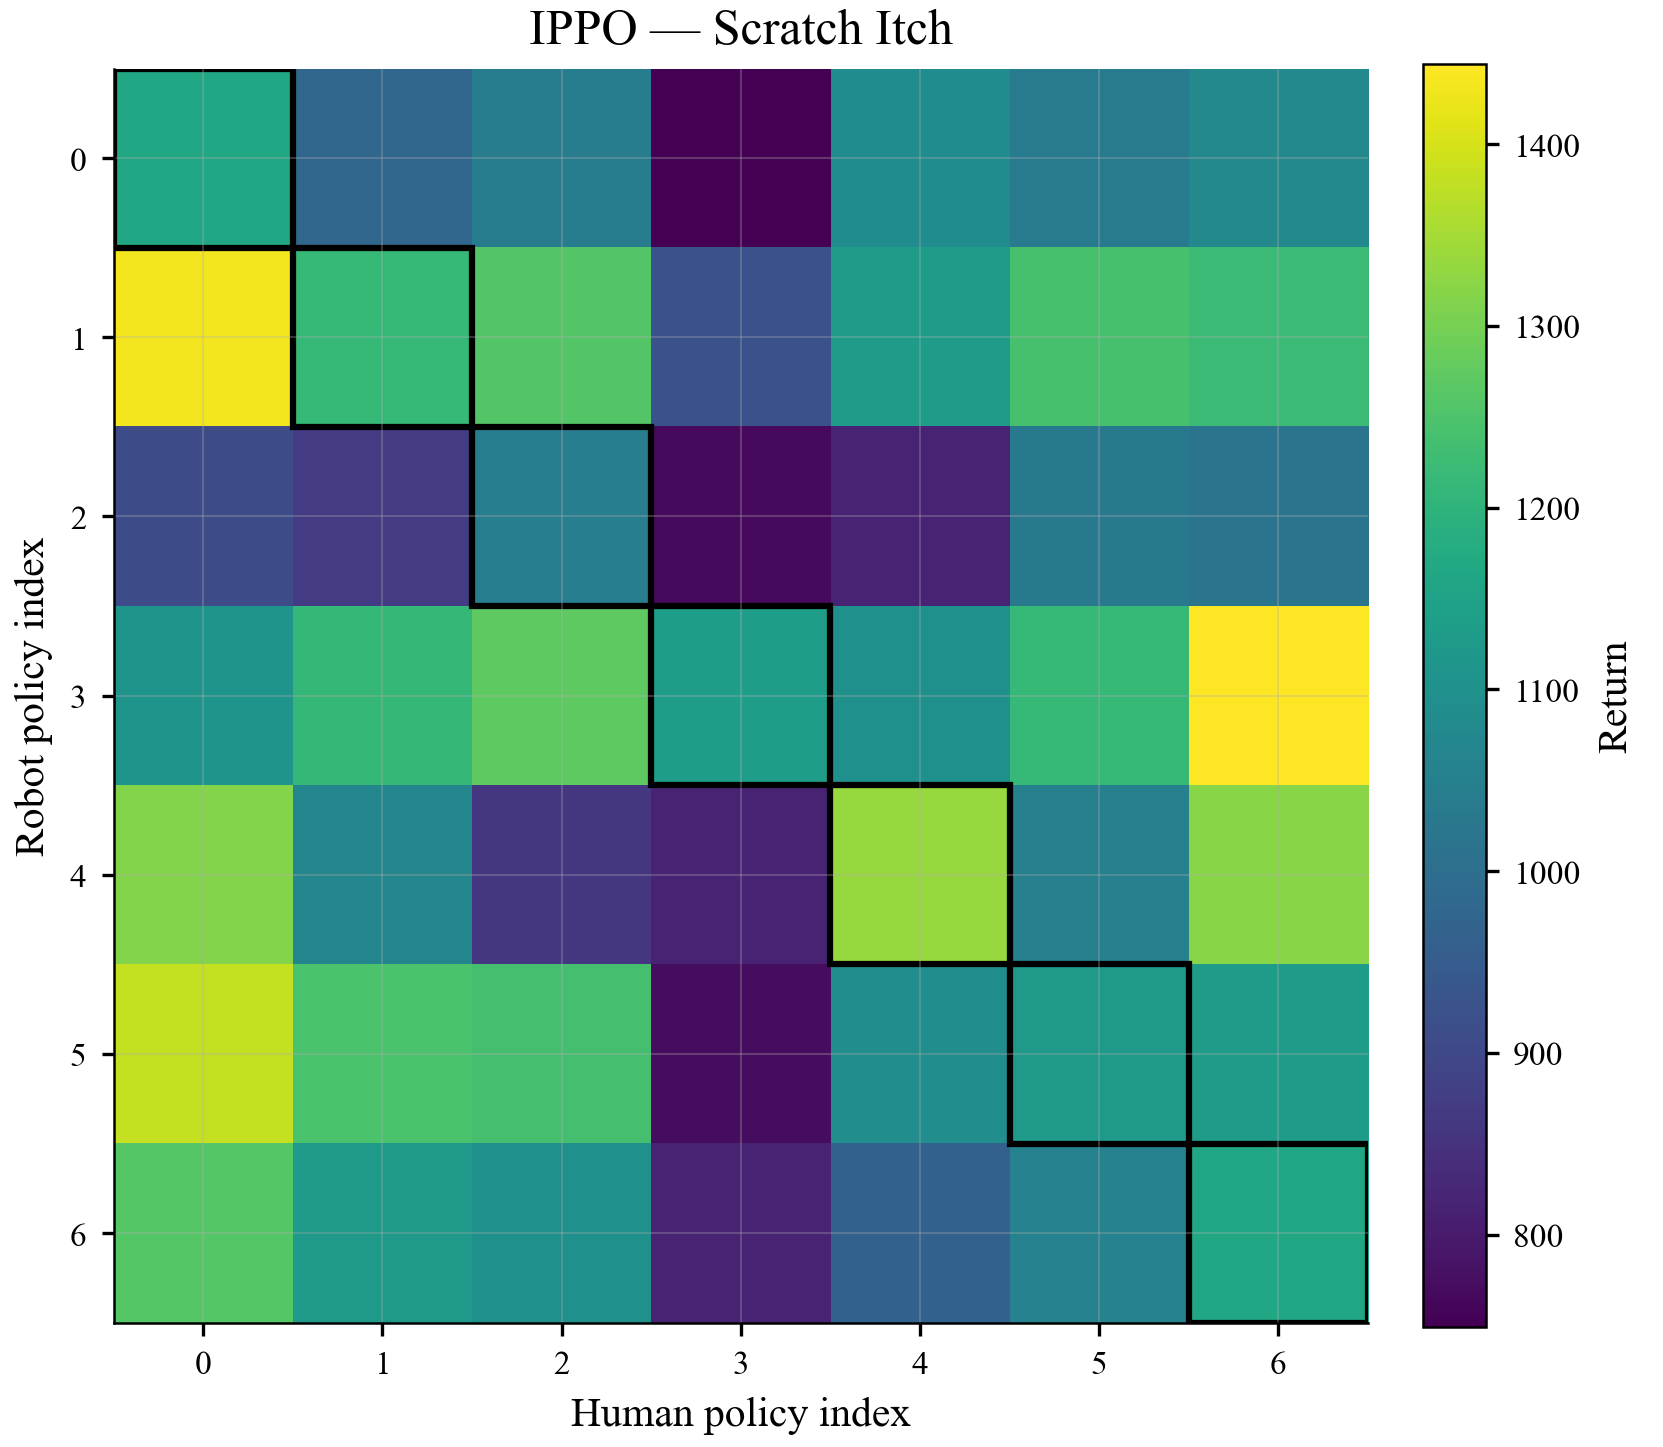

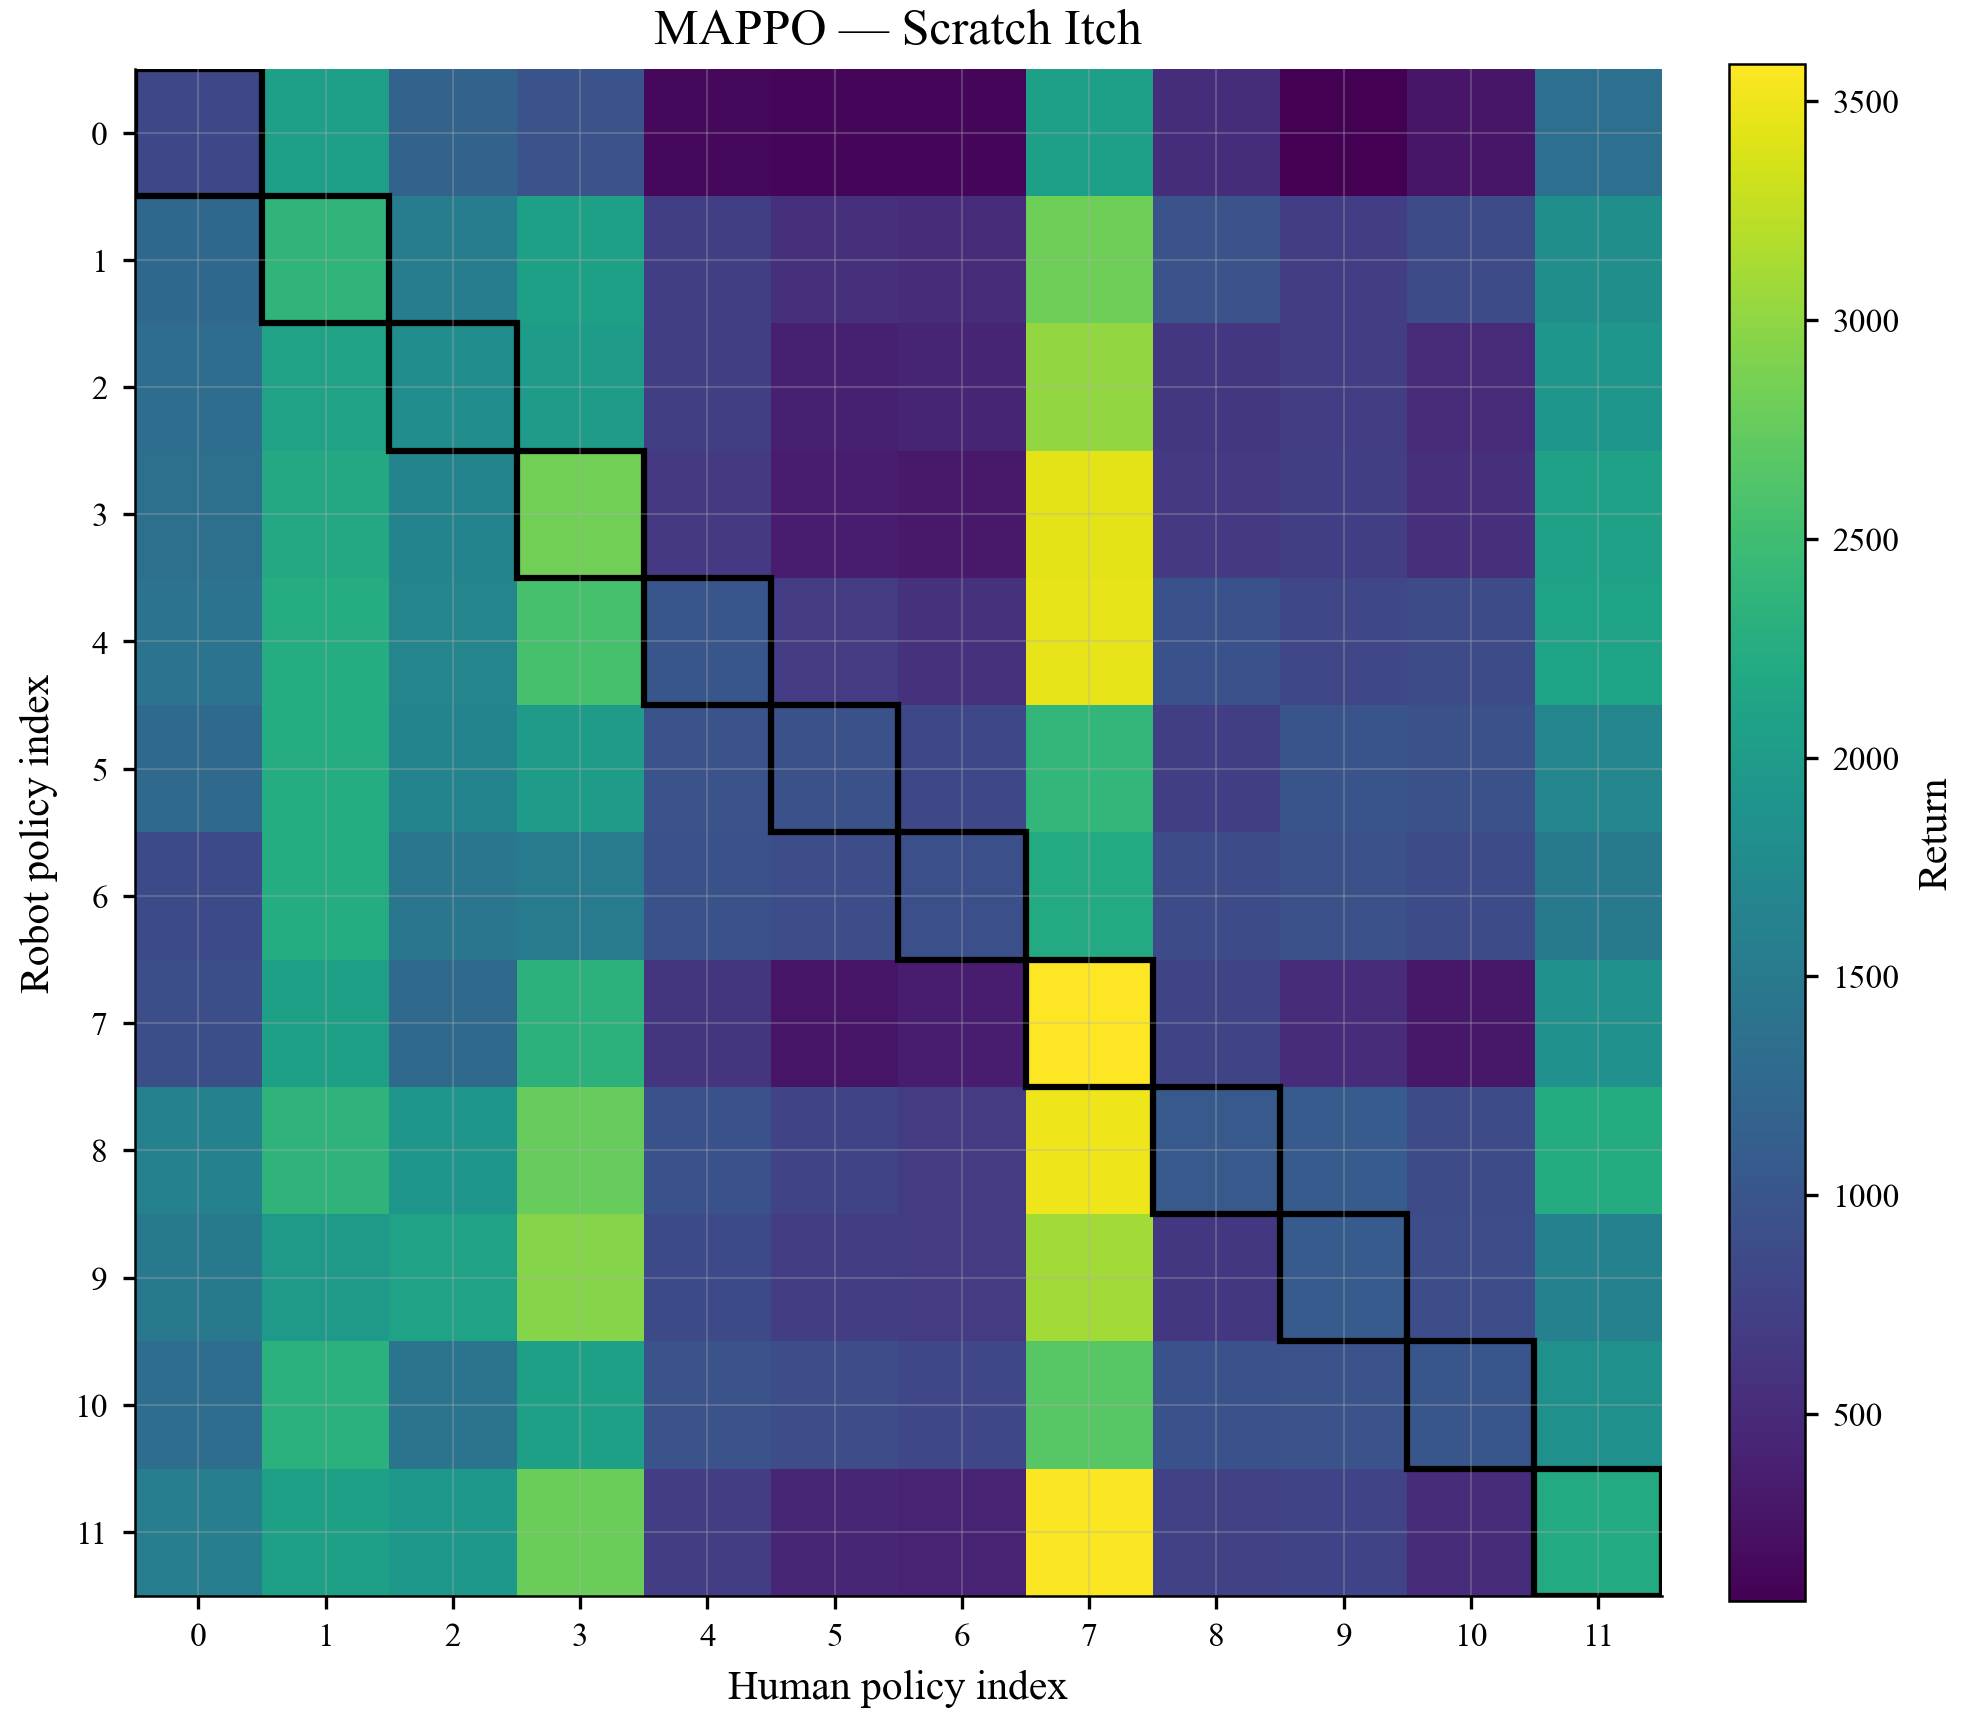

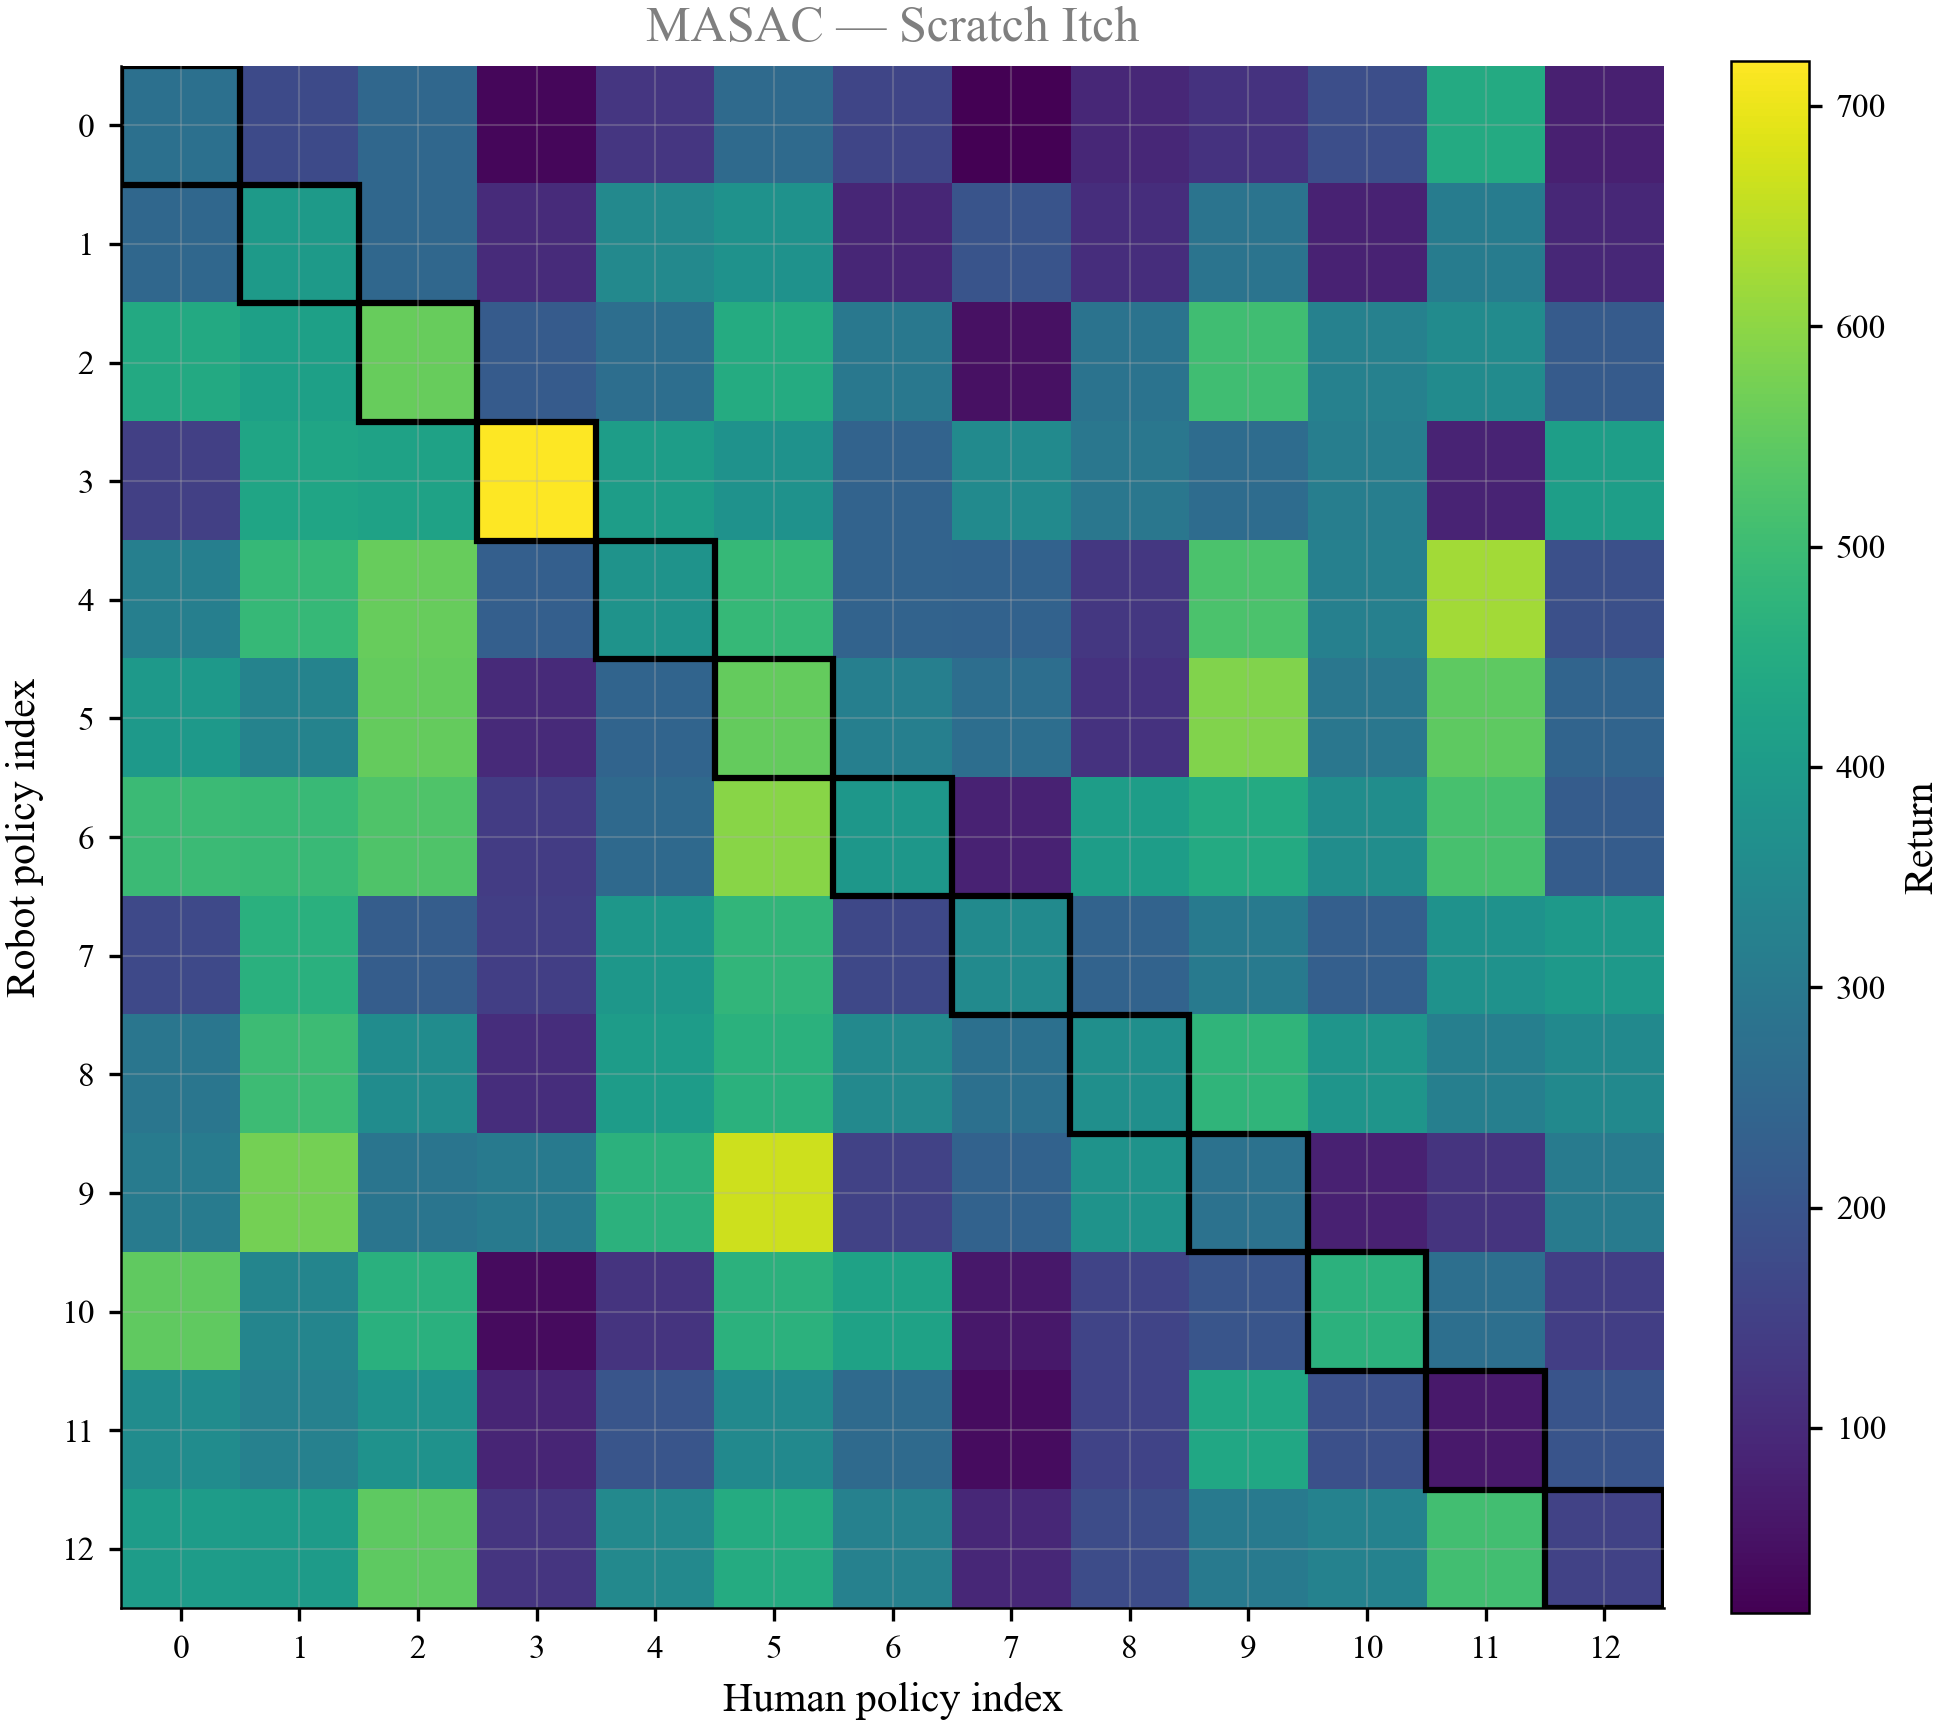

In [19]:
from assistax.baselines.crossplay_plots import plot_all_crossplay

crossplay_results_path = "/home/leo/assistive-autonomy-github/crossplay_data/0/crossplay_results.npy"  # TODO: update path

plot_all_crossplay(
    results_path=crossplay_results_path,
    save_dir="figs/",
    env_name="scratchitch",
    usetex_fallback=True,
)

## Crossplay Diagonal Alignment Diagnostic

Verify that co-trained teams (shared `team_uuid`) are correctly placed on the
matrix diagonal, i.e. `matrix[i,i]` = robot-i evaluated against its trained
partner human-i.

## Combined Crossplay Heatmap

Saved: figs/crossplay_combined.pdf


(<Figure size 2025x2025 with 2 Axes>,
 <Axes: xlabel='Human policy index', ylabel='Robot policy index'>)

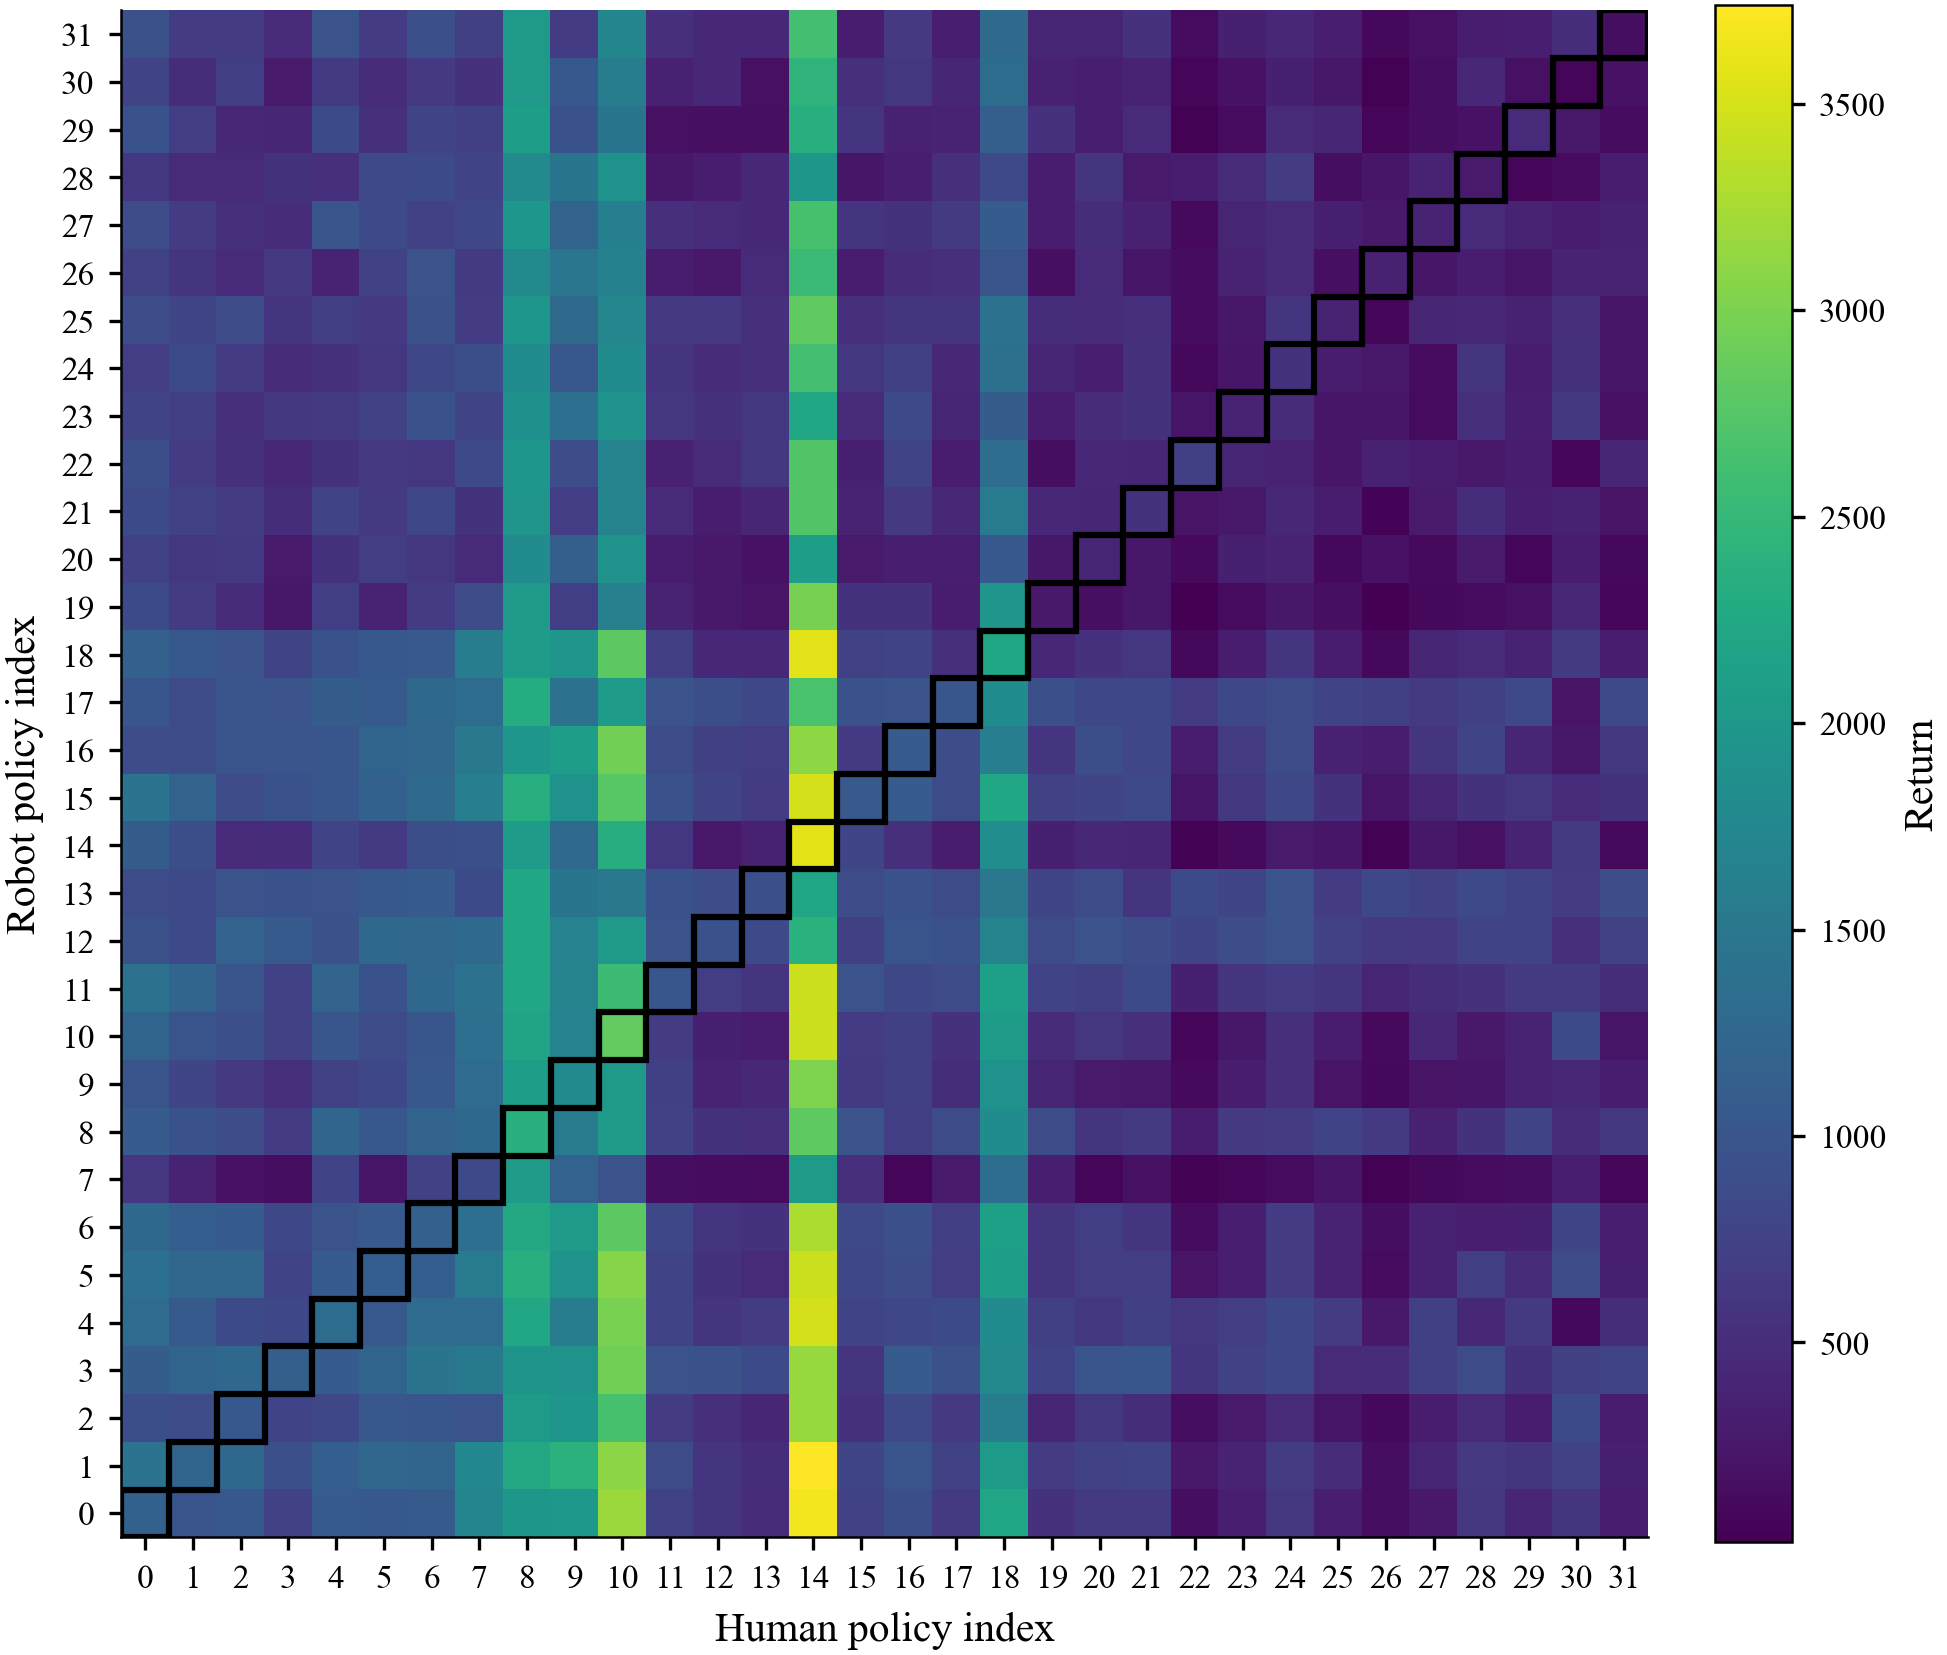

In [20]:
from assistax.baselines.crossplay_plots import plot_combined_crossplay

plot_combined_crossplay(
    results_path=crossplay_results_path,
    save_path="figs/crossplay_combined.pdf",
    usetex_fallback=True,
)